In [1]:
import os
os.environ['KAGGLE_API_TOKEN'] ="KGAT_bdd2e332300779ac676ceb7010ceb0c9"

In [2]:
!pip install scikit-learn==1.6.0
!pip install -q kaggle
!kaggle datasets download -d uciml/adult-census-income

Dataset URL: https://www.kaggle.com/datasets/uciml/adult-census-income
License(s): CC0-1.0
100% 450k/450k [00:00<00:00, 50.5MB/s]



In [3]:
import zipfile
with zipfile.ZipFile('adult-census-income.zip', 'r') as zip_ref:
    zip_ref.extractall()
print("Dataset is ready")

Dataset is ready


In [113]:
import pandas as pd
df = pd.read_csv('adult.csv')
print(f"Dataset Shape: {df.shape}")
df.head(50)

Dataset Shape: (32561, 15)


# **Data Preprcoessing**

In [6]:
import numpy as np

df.replace('?', np.nan, inplace=True)
df.fillna('Unknown', inplace=True)
df.head(100)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Unknown,77053,HS-grad,9,Widowed,Unknown,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Unknown,186061,Some-college,10,Widowed,Unknown,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,46,Private,192963,Bachelors,13,Married-civ-spouse,Adm-clerical,Husband,Asian-Pac-Islander,Male,0,2415,35,Philippines,>50K
96,46,Self-emp-not-inc,198759,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,2415,80,United-States,>50K
97,39,Self-emp-inc,143123,Assoc-voc,11,Married-civ-spouse,Craft-repair,Husband,White,Male,0,2415,40,United-States,>50K
98,39,Private,237713,Prof-school,15,Married-civ-spouse,Sales,Husband,White,Male,0,2415,99,United-States,>50K


In [7]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['native.country'] = label_encoder.fit_transform(df['native.country'])
df['occupation'] = label_encoder.fit_transform(df['occupation'])
df['race'] = label_encoder.fit_transform(df['race'])
df['sex'] = label_encoder.fit_transform(df['sex'])
df['relationship'] = label_encoder.fit_transform(df['relationship'])
df['marital.status'] = label_encoder.fit_transform(df['marital.status'])
df['education'] = label_encoder.fit_transform(df['education'])
df['workclass'] = label_encoder.fit_transform(df['workclass'])
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,7,77053,11,9,6,14,1,4,0,0,4356,40,38,<=50K
1,82,3,132870,11,9,6,3,1,4,0,0,4356,18,38,<=50K
2,66,7,186061,15,10,6,14,4,2,0,0,4356,40,38,<=50K
3,54,3,140359,5,4,0,6,4,4,0,0,3900,40,38,<=50K
4,41,3,264663,15,10,5,9,3,4,0,0,3900,40,38,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,3,310152,15,10,4,10,1,4,1,0,0,40,38,<=50K
32557,27,3,257302,7,12,2,12,5,4,0,0,0,38,38,<=50K
32558,40,3,154374,11,9,2,6,0,4,1,0,0,40,38,>50K
32559,58,3,151910,11,9,6,0,4,4,0,0,0,40,38,<=50K


# **Victim** **Model**

In [82]:
y = df['income']
X = df.drop(['income'], axis=1)

In [94]:
from sklearn.model_selection import train_test_split
X_trainset, X_testset, y_trainset, y_testset = train_test_split(X, y, test_size=0.5,random_state=42, stratify=y)

In [149]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
incomeTree = DecisionTreeClassifier(criterion="entropy", max_depth= 100, min_samples_leaf=5, min_samples_split=2, random_state=42)
incomeTree.fit(X_trainset,y_trainset)
print(f"Train Acc: {incomeTree.score(X_trainset, y_trainset):.2%}")
print(f"Test Acc: {incomeTree.score(X_testset, y_testset):.2%}")

Train Acc: 92.33%
Test Acc: 82.59%


Dataset for attack model

In [150]:
from scipy.stats import entropy
from sklearn.metrics import log_loss

# 1. Get raw probabilities
mem_probs = incomeTree.predict_proba(X_trainset)
non_mem_probs = incomeTree.predict_proba(X_testset)

# 2. Calculate Entropy
mem_entropy = [entropy(p) for p in mem_probs]
non_mem_entropy = [entropy(p) for p in non_mem_probs]

# 3. Calculate Log-Loss (Small values = Member, Large = Non-Member)
# We calculate this row-by-row
mem_loss = [log_loss([y], [p], labels=[0,1]) for y, p in zip(y_trainset, mem_probs)]
non_mem_loss = [log_loss([y], [p], labels=[0,1]) for y, p in zip(y_testset, non_mem_probs)]

# 4. Assemble the Master Attack Dataset
df_attack = pd.DataFrame({
    'confidence': np.concatenate([np.max(mem_probs, axis=1), np.max(non_mem_probs, axis=1)]),
    'is_correct': np.concatenate([(incomeTree.predict(X_trainset) == y_trainset).astype(int),
                                 (incomeTree.predict(X_testset) == y_testset).astype(int)]),
    'entropy': np.concatenate([mem_entropy, non_mem_entropy]),
    'log_loss': np.concatenate([mem_loss, non_mem_loss]),
    'is_member': np.concatenate([np.ones(len(mem_probs)), np.zeros(len(non_mem_probs))])
})

df_attack = df_attack.sample(frac=1, random_state=42).reset_index(drop=True)
print("Master Attack Dataset Ready with 4 Features!")

Master Attack Dataset Ready with 4 Features!


# **Attack Model**

In [151]:
# Updated Cell 13
X_attack = df_attack[['confidence', 'is_correct', 'entropy', 'log_loss']]
y_attack = df_attack['is_member']

# Now re-run your Random Forest training in Cell 15

In [152]:
X_train_atk, X_test_atk, y_train_atk, y_test_atk = train_test_split(X_attack, y_attack, test_size=0.2, random_state=42)

In [153]:
# Train the Random Forest
hacker_rf = RandomForestClassifier(n_estimators=100, random_state=42)
hacker_rf.fit(X_train_atk, y_train_atk)

# Check the new Success Rate
final_acc = hacker_rf.score(X_test_atk, y_test_atk)
print(f"New Attack Success Rate: {final_acc:.2%}")

New Attack Success Rate: 55.14%


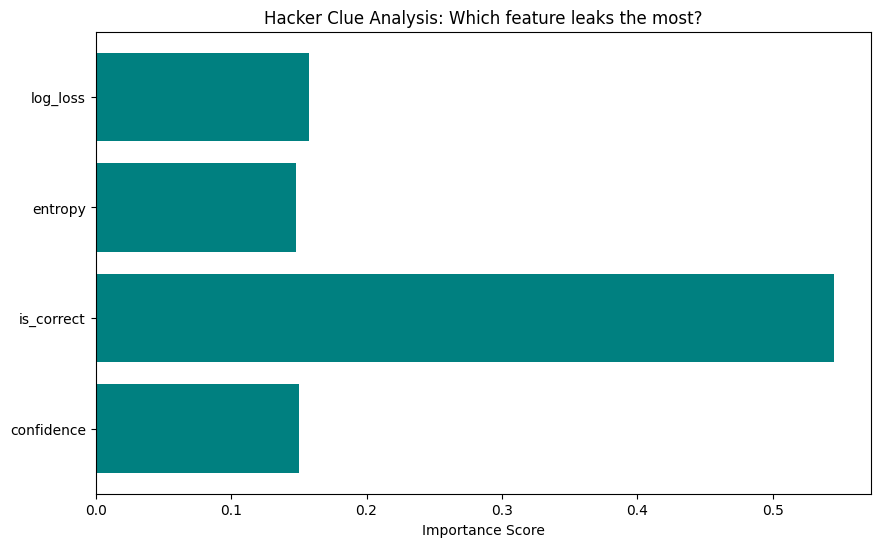

In [154]:
import matplotlib.pyplot as plt

# Get importances from your hacker_rf
importances = hacker_rf.feature_importances_
features = X_attack.columns

plt.figure(figsize=(10, 6))
plt.barh(features, importances, color='teal')
plt.xlabel('Importance Score')
plt.title('Hacker Clue Analysis: Which feature leaks the most?')
plt.show()

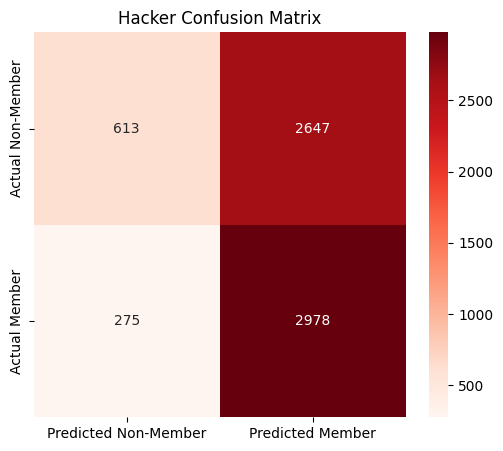

              precision    recall  f1-score   support

         0.0       0.69      0.19      0.30      3260
         1.0       0.53      0.92      0.67      3253

    accuracy                           0.55      6513
   macro avg       0.61      0.55      0.48      6513
weighted avg       0.61      0.55      0.48      6513



In [155]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred_atk = hacker_rf.predict(X_test_atk)
cm = confusion_matrix(y_test_atk, y_pred_atk)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Non-Member', 'Predicted Member'],
            yticklabels=['Actual Non-Member', 'Actual Member'])
plt.title('Hacker Confusion Matrix')
plt.show()

print(classification_report(y_test_atk, y_pred_atk))

In [157]:
def check_person_leak(age, education_num, occupation, hours_per_week):
    """
    Simulates checking if a specific person's profile is leaked.
    (You can add more features like 'capital-gain' to make it more precise)
    """
    # 1. Create the person's profile (using the same structure as your X_trainset)
    # Note: We fill other columns with '0' or averages for this demo
    person_data = pd.DataFrame(0, index=[0], columns=X_trainset.columns)
    person_data['age'] = age
    person_data['education.num'] = education_num
    person_data['occupation'] = occupation
    person_data['hours.per.week'] = hours_per_week

    # 2. Get the Victim's "Reaction"
    prob = incomeTree.predict_proba(person_data)
    pred = incomeTree.predict(person_data)

    # 3. Extract the Hacker's Clues
    conf = np.max(prob, axis=1)[0]
    ent = entropy(prob[0])
    # For this test, we assume the model guessed 'Correct' to see the worst-case leak
    loss = log_loss([pred[0]], prob, labels=[0, 1])

    # 4. Ask the Hacker
    hacker_input = pd.DataFrame([[conf, 1, ent, loss]],
                                columns=['confidence', 'is_correct', 'entropy', 'log_loss'])
    leak_score = hacker_rf.predict_proba(hacker_input)[0][1]

    print(f"--- PRIVACY AUDIT REPORT ---")
    print(f"Profile: Age {age}, Occupation Code {occupation}")
    print(f"Hacker's Certainty: {leak_score:.2%}")

    if leak_score > 0.80:
        print("❌ STATUS: HIGH RISK. This person's profile is highly 'recognizable' by the model.")
    elif leak_score > 0.55:
        print("⚠️ STATUS: MODERATE RISK. Possible membership leakage.")
    else:
        print("✅ STATUS: SECURE. The model treats this person as a stranger.")

# TEST IT NOW:
check_person_leak(age=45, education_num=13, occupation=4, hours_per_week=40)

--- PRIVACY AUDIT REPORT ---
Profile: Age 45, Occupation Code 4
Hacker's Certainty: 60.16%
⚠️ STATUS: MODERATE RISK. Possible membership leakage.
